<a href="https://colab.research.google.com/github/SonalShukla-projects/Bankruptcy_Prediction_Company_ML_Project/blob/main/notebooks/08_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.listdir())


['.config', 'sample_data']


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_path = "/content/drive/MyDrive/ML_Project_Results"

In [5]:
# 80:20 results
lr80 = pd.read_csv(f"{base_path}/logistic_results.csv")
dt80 = pd.read_csv(f"{base_path}/decision_tree_results.csv")
knn80 = pd.read_csv(f"{base_path}/knn_results.csv")
rf80 = pd.read_csv(f"{base_path}/random_forest_results.csv")
svm80 = pd.read_csv(f"{base_path}/svm_results.csv")
xgb80 = pd.read_csv(f"{base_path}/xgboost_results.csv")

In [6]:
# Add split column
for df in [lr80, dt80, knn80, rf80, svm80, xgb80]:
    df["Split"] = "80:20"


In [7]:
# 70:30 results
lr70 = pd.read_csv(f"{base_path}/logistic_70_30.csv")
dt70 = pd.read_csv(f"{base_path}/decision_tree_70_30.csv")
knn70 = pd.read_csv(f"{base_path}/knn_70_30.csv")
rf70 = pd.read_csv(f"{base_path}/random_forest_70_30.csv")
svm70 = pd.read_csv(f"{base_path}/svm_smote_70_30.csv")  # IMPORTANT (SMOTE)
xgb70 = pd.read_csv(f"{base_path}/xgboost_70_30.csv")

In [8]:
comparison = pd.concat([
    lr80, dt80, knn80, rf80, svm80, xgb80,
    lr70, dt70, knn70, rf70, svm70, xgb70
])

comparison.reset_index(drop=True, inplace=True)

# Reorder columns
comparison = comparison[["Model", "Split", "Accuracy", "Precision", "Recall", "F1"]]

comparison

,Model,Split,Accuracy,Precision,Recall,F1
0,Logistic Regression,80:20,0.962854,0.541667,0.166667,0.254902
1,Decision Tree,80:20,0.950880,0.346154,0.352941,0.349515
2,KNN,80:20,0.963343,0.545455,0.117647,0.193548
3,Random Forest,80:20,0.966276,0.727273,0.156863,0.258065
4,SVM,80:20,0.963343,1.000000,0.019608,0.038462
5,XGBoost,80:20,0.965543,0.576923,0.294118,0.389610
6,Logistic Regression,70:30,0.962854,0.541667,0.166667,0.254902
7,Decision Tree,70:30,0.947214,0.321429,0.346154,0.333333
8,KNN,70:30,0.961877,0.500000,0.128205,0.204082
9,Random Forest,70:30,0.964809,0.714286,0.128205,0.217391


In [9]:
comparison.to_csv("final_model_comparison.csv", index=False)

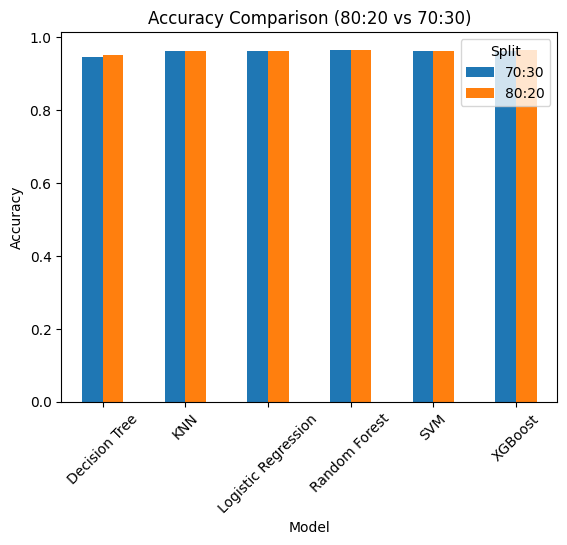

In [10]:
comparison.pivot(index="Model", columns="Split", values="Accuracy").plot(kind="bar")

plt.title("Accuracy Comparison (80:20 vs 70:30)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

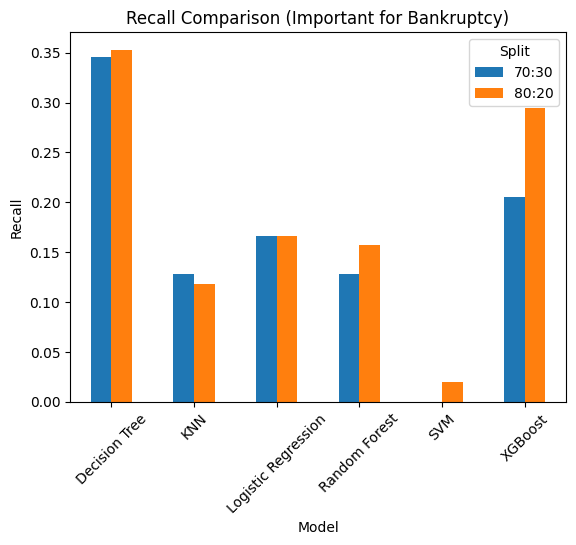

In [11]:
comparison.pivot(index="Model", columns="Split", values="Recall").plot(kind="bar")

plt.title("Recall Comparison (Important for Bankruptcy)")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.show()

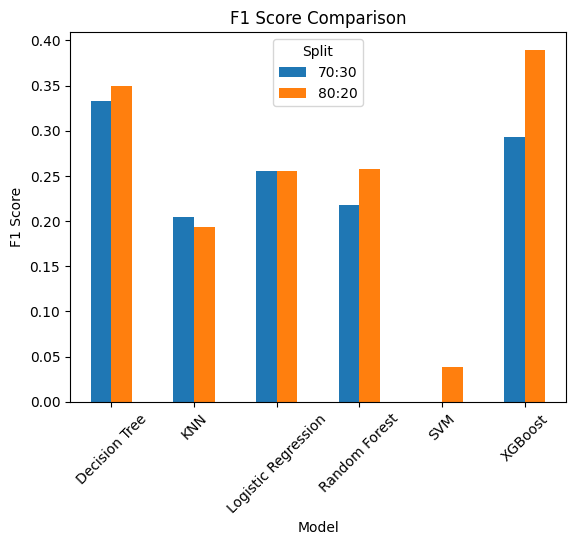

In [12]:
comparison.pivot(index="Model", columns="Split", values="F1").plot(kind="bar")

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

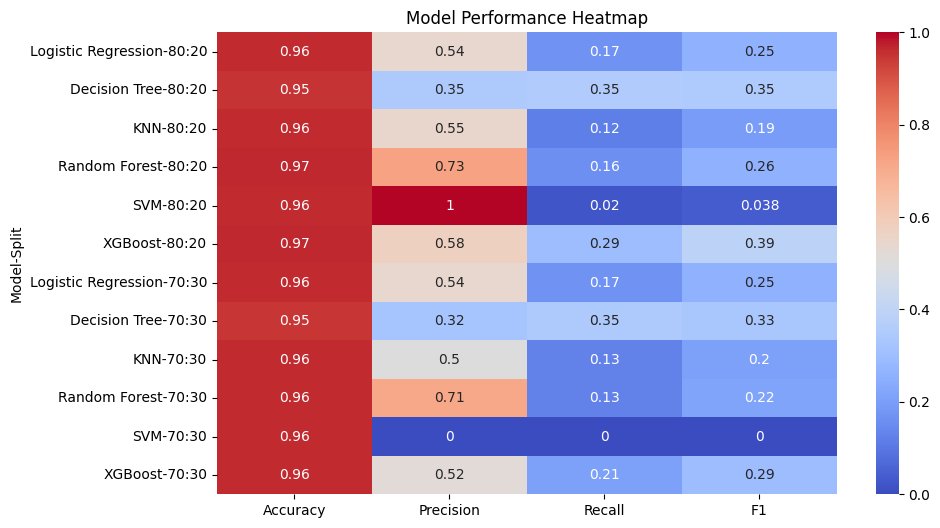

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(comparison.set_index(["Model","Split"]), annot=True, cmap="coolwarm")

plt.title("Model Performance Heatmap")
plt.show()

In [14]:
best_model = comparison.sort_values(by="Recall", ascending=False).iloc[0]

print("Best Model Based on Recall:")
print(best_model)

Best Model Based on Recall:
Model        Decision Tree
Split                80:20
Accuracy           0.95088
Precision         0.346154
Recall            0.352941
F1                0.349515
Name: 1, dtype: object
